In [3]:
import numpy as np
from math import *
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy

Pour toute la suite, on se place sur un certain espace probabilisé $(\Omega, \mathcal F, \mathbb P)$. 

# 2) Illustrer des convergences (HYPER IMPORTANT)

Cette partie est (selon moi) LA PLUS IMPORTANTE !! Dans quasiment tous les textes, on peut caser des illustrations de convergence, et ça c'est super, parce que déjà c'est facile à faire, et en plus ça permet parfois de tendre des perches pour des questions pas trop dures sur vos simulations ou sur les théorèmes limites que vous connaissez par coeur ! 

## 2.1) Illustrer une convergence presque-sûre 

Faisons un exemple avec l'illustration de l'incontournable loi des grands nombres : on se donne $(X_i)_{i \ge 1}$ une suite de variables aléatoires iid et $L^1$, de moyenne $\mu $. On a alors la convergence presque sûre suivante: 
$$\frac{S_n}{n} \xrightarrow[n \to \infty]{\text{p.s.}} \mu, $$
où $S_n= \displaystyle \sum_{i=1}^n X_i $. 

Pour faire un exemple, nous allons prendre des variables de loi exponentielle de paramètre $\lambda$, et donc de moyenne $\frac{1}{\lambda}$. La convergence presque sûre étant préservée par applications de fonctions continues, on a alors la convergence suivante: 
$$\frac{n}{S_n} \xrightarrow[n \to \infty]{\text{p.s.}} \lambda. $$

Pour illustrer cette convergence, on travaille TRAJECTOIRE PAR TRAJECTOIRE : on simule un vecteur $[X_1, \dots, X_n]$ où les $X_i$ sont des variables exponentielles de paramètre $\lambda$, et puis on trace les $k/S_k$ en fonction de $k$, où $S_k= \displaystyle \sum_{i=1}^k X_i $.

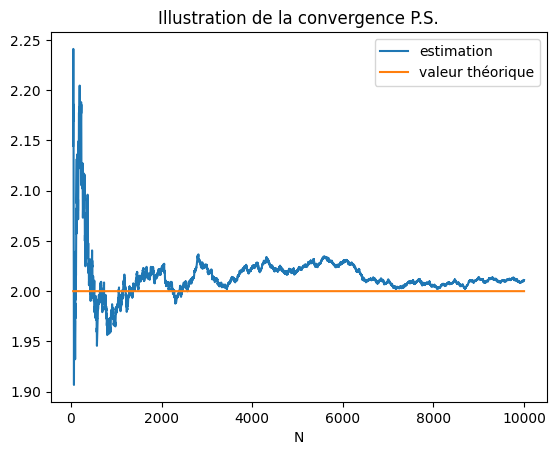

In [7]:
def illustration_cv_ps(l,n): # ATTENTION, la convergence PS s'illustre trajectoire par trajectoire !!! 
    T=stats.expon.rvs(scale=1/l, size=n)
    E=[]
    N=np.arange(50,n+1) # Je commence à 50 pour ne pas avoir trop des pics abberants aux premières valeurs qui écrasent tout le graphique
    L=[l for i in N]
    for i in N:
        Ti=T[:i]
        estim=len(Ti)/np.sum(Ti)
        E.append(estim)
    plt.xlabel('N')
    plt.plot(N,E,label='estimation')
    plt.plot(N,L,label='valeur théorique')
    plt.title('Illustration de la convergence P.S.')
    plt.legend()
    plt.show()

illustration_cv_ps(2,10000) 

Si la convergence p.s. que vous voulez illustrer est de la forme 
$$X_n \xrightarrow[n \to \infty]{\text{p.s.}} X,$$
où $X$ est une variable NON CONSTANTE, alors il va être plus compliqué d'illustrer que la limite de $X_n$ est $X$ contrairament au cas constant. Ce que vous pouvez faire en revanche, c'est faire d'abord une illustration du fait que $X_n$ converge presque sûrement, en simulant plusieurs trajectoires pour montrer qu'elles convergent toutes, PUIS une illustration de la convergence en loi, pour au moins montrer que la limite a la même loi que $X$.

Exemple avec la martingale du TP7 : on définit 
$$M_n = \sum_{k=1}^n \frac{X_k}{k}$$
où les $(X_k)_{k \ge 1}$ sont des normales centrées réduites indépendantes. Alors $(M_n)_{n \ge 1}$ est bornée dans $L^2$, et donc converge p.s. et dans $L^2$. On peut d'abord illustrer la convergence p.s. grâce à la convergence des trajectoires. 

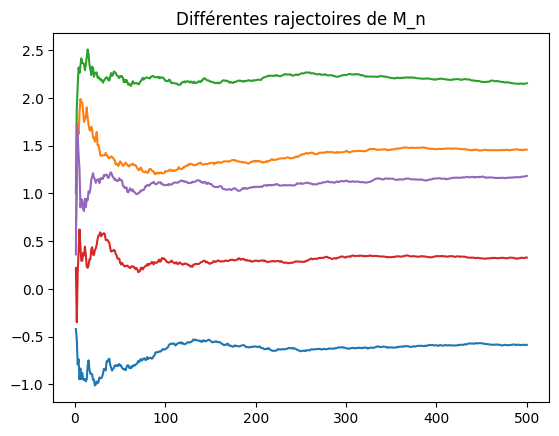

In [18]:
n=500
N=np.arange(1,n+1)
X1=np.cumsum(stats.norm.rvs(size=n)/N)
X2=np.cumsum(stats.norm.rvs(size=n)/N)
X3=np.cumsum(stats.norm.rvs(size=n)/N)
X4=np.cumsum(stats.norm.rvs(size=n)/N)
X5=np.cumsum(stats.norm.rvs(size=n)/N)
plt.plot(N,X1)
plt.plot(N,X2)
plt.plot(N,X3)
plt.plot(N,X4)
plt.plot(N,X5)
plt.title('Différentes rajectoires de M_n') 
plt.show()

Puis on montre
$$M_n \xrightarrow[n \to \infty]{\mathcal L} \mathcal{N}\left ( 0, \frac {\pi ^2}{6}\right ),$$
ce que l'on peut illustrer avec les techniques classiques d'illustration de la convergence en loi (cf partie suivante). 

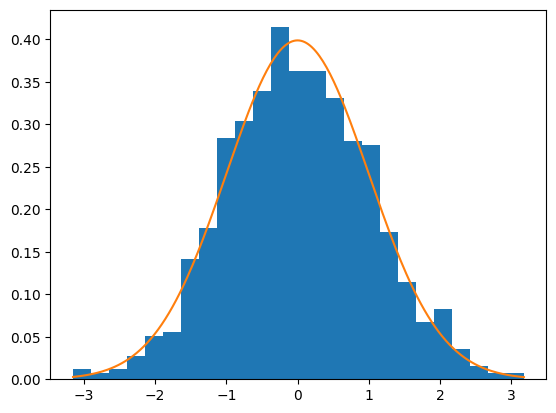

In [15]:
n=1000
N=1000
M=[]
for _ in range (N): 
    M.append(np.sum(stats.norm.rvs(size=n)/np.arange(1,n+1)))
M=(sqrt(6)/pi)*np.array(M)
plt.hist(M,25,density='True', label='histogramme échantillon')
X=np.linspace(min(M),max(M),250)
plt.plot(X,stats.norm.pdf(X),label='densité loi normale')
plt.show()

## 2.2) Illustrer une convergence en loi 

Evidemment, la convergence en loi que vous serez le plus amené.e.s à illustrer sera le théorème central limite : soit $(X_i)_{i\ge 1}$ une suite de variables aléatoires iid et $L^2$, de moyenne $\mu$ et de variance $\sigma^2$, on a alors la convergence en loi suivante:
$$\sqrt n \left(\frac{S_n}{n} - \mu \right)\xrightarrow[n \to \infty]{\mathcal L } \mathcal N (0,\sigma^2),$$
autrement dit, (formulation plus facile à illustrer numériquement) 
$$\frac{\sqrt n}{\sigma} \left(\frac{S_n}{n} - \mu \right)\xrightarrow[n \to \infty]{\mathcal L } \mathcal N (0,1). $$
C'est donc ce théorème que l'on va illustrer dans la suite. 


### 2.2.1) A l'aide de la fonction de répartition empirique 

Imaginons que l'on veuille montrer une convergence en loi de la forme 
$$E_n \xrightarrow[n \to \infty]{\mathcal L } E.  $$


Une première façon de faire est d'utiliser les fonctions de répartitions empiriques. Pour cela, on simule un échantillon de taille $N$ de variables $(E^k_n)_{1 \le k \le N}$, et puis on trace la fonction de répartition empirique des $(E_n^k)_{1 \le k \le N}$ qui est donnée par 
$$F_n^N(x)= \frac{1}{N} \sum_{k=1}^N \mathbb{1}_{E_n^k \le x },$$
que l'on compare à la fonction de répartition de $E$.
Une façon astucieuse de faire, c'est juste de tracer le vecteur $[i/N \text{ for i in range } (1,N+1)]$ en fonction de $[E^{(1)}_n, \dots, E^{(N)}_n]$, où $E^{(1)}_n, \dots, E^{(N)}_n$ est l'échantillon trié. 

Cette méthode se base sur 2 convergences. Tout d'abord, elle repose sur le fait que la convergence en loi implique la convergence des fonctions de répartition en tout point de continuité de la fonction de répartition limite (donc partout si $E$ est à densité, ce qui est le cas pour les convergences données par le TCL). Autrement dit, si l'on note $F_n$ la fonction de répartition de $(E_n^k)_{1 \le k \le N}$ (qui ont tous la même loi) et $F$ la fonction de répartition $E$ (que l'on suppose à densité), on a 
$$F_n \xrightarrow[n \to \infty]{\text{cv simple} } F. $$
Ensuite, le deuxième théorème que l'on utilise pour justifier cette méthode, c'est le théorème de Glivenko Cantelli, qui nous dit que, à $n$ fixé, lorsque $N$ tend vers l'infini, la fonction de répartition empirique $F_n^N$ converge vers la fonction de répartition $F_n$: 
$$\Vert F_n^N - F_n \Vert_ \infty \xrightarrow[N \to \infty]{\text{p.s.}} 0. $$


Illustrons, via cette méthode, le TCL dans le cas où les $(X_i)_{i \ge 1}$ suivent loi exponentielle de paramètre $\lambda$ (et donc de moyenne $\frac{1}{\lambda}$ et de variance $\frac{1}{\lambda ^2}$). Le TCL nous donne :  
$$\sqrt n \left(\frac{S_n}{n} - \frac{1}{\lambda} \right)\xrightarrow[n \to \infty]{\mathcal L } \mathcal N (0,\frac{1}{\lambda^2}). $$
Donc en appliquant la $\delta$ méthode avec la fonction $x \mapsto \frac{1}{x}$, on obtient : 
$$\sqrt n \left(\frac{n}{S_n} - \lambda \right)\xrightarrow[n \to \infty]{\mathcal L } \mathcal N (0,\lambda^2), $$ 
c'est à dire : 
$$\frac{\sqrt n}{\lambda} \left(\frac{n}{S_n} - \lambda \right)\xrightarrow[n \to \infty]{\mathcal L } \mathcal N (0,1). $$ 
Dans ce cas, 
$$E_n = \frac{\sqrt n}{\lambda} \left(\frac{n}{S_n} - \lambda \right). $$
Et donc pour illustrer cette convergence, on simule $N$ échantillons indépendants de taille $n$ que l'on note $(X_i^k)_{1 \le i \le n }$ pour $1 \le k \le N$. Ensuite, pour chaque échantillon, on calcule 
$$E_n^k = \frac{S_n^k - n\mu }{\sqrt{n} \sigma},  $$
où $S_n^k= \displaystyle \sum_{i=1}^n X_i^k $, et puis on applique la méthode précédente. 

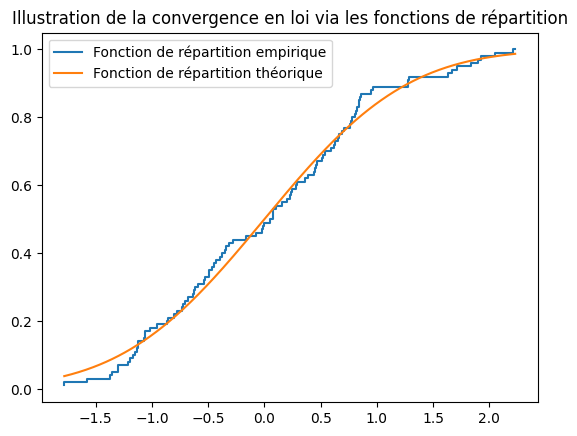

In [4]:
def illustration_cv_loi_fdr_exp(l,n,N):
    M=stats.expon.rvs(scale=1/l,size=(N,n))
    E=(sqrt(n)/l)*((n/np.sum(M, axis=1))-l) # faire une boucle for si vous êtes plus à l'aise avec ça !! 
    E=np.sort(E)
    F_emp=np.arange(1,N+1)/N
    plt.plot(E,F_emp,drawstyle='steps-pre',label='Fonction de répartition empirique')
    
    X = np.linspace(min(E),max(E),500)
    F_th=stats.norm.cdf(X) # par défaut, la loi normale est la centrée réduite 
    plt.plot(X,F_th,label='Fonction de répartition théorique')
    
    plt.title('Illustration de la convergence en loi via les fonctions de répartition')
    plt.legend()
    plt.show()

illustration_cv_loi_fdr_exp(2,500,100)

Pour avoir un exemple avec des variables discrètes, voilà ci-dessous une autre illustration du TCL, cette fois dans le cas où les $(X_i)_{i \ge 1}$ suivent une loi de Bernoulli de paramètre $p$. Le TCL correspondant s'écrit 
$$\frac{S_n - np }{\sqrt{np(1-p)} } \xrightarrow[n \to \infty]{\mathcal L } \mathcal N (0,1), $$
Illustrons cela via la même méthode (même méthode de simulation malgré le fait que les variables de départ soient discrètes).

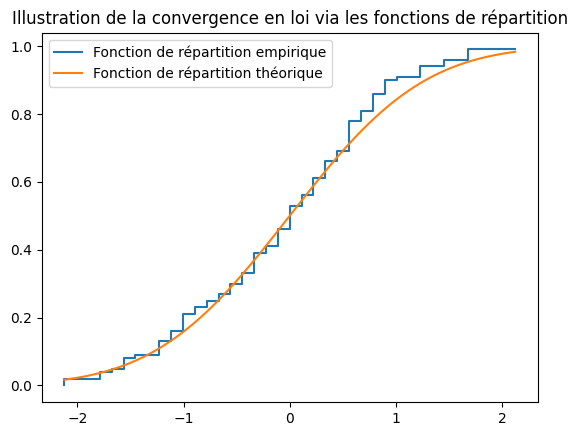

In [13]:
def illustration_cv_loi_fdr_bern(p,n,N):
    M=stats.binom.rvs(n,p,size=N) #on simule directement les sommes avec des binomiales 
    E=(M-n*p)/sqrt(n*p*(1-p))
    E=np.sort(E)
    F_emp=np.arange(N)/N
    plt.plot(E,F_emp,drawstyle='steps-pre',label='Fonction de répartition empirique')
    
    X = np.linspace(min(E),max(E),500)
    F_th=stats.norm.cdf(X,loc=0,scale=1)
    plt.plot(X,F_th,label='Fonction de répartition théorique')
    
    plt.title('Illustration de la convergence en loi via les fonctions de répartition')
    plt.legend()
    plt.show()

illustration_cv_loi_fdr_bern(0.8,500,100)

### 2.2.2) A l'aide d'histogrammes et de densité (cas continu) 

Une deuxième façon d'illustrer une convergence en loi de la forme 
$$E_n \xrightarrow[n \to \infty]{\mathcal L } E $$
dans le cas où tout le monde est à densité, c'est de comparer un histogramme empirique et une densité limite. Pour cela, on simule un échantillon de taille $N$ de variables $(E^k_n)_{1 \le k \le N}$, et cette fois, on fait un histogramme de cet échantillon que l'on compare à la densité de $E$. 

Mais ATTENTION aux affirmations concernant la convergence des histogrammes, il existe des théorèmes de convergence, mais ils ne sont pas au programme (et pas évidents), alors selon moi il est toujours bien d'avoir en plus en backup une illustration dont on sait prouver la validité (fonctions empiriques ou test de KS). Mais bon, c'est toujours joli et convaincant alors autant apprendre à faire ça bien. 

De nouveau, on commence par illustrer la convergence en loi donnée par le TCL pour des variables exponentielles, la méthode pour obtenir l'échantillon $(E^k_n)_{1 \le k \le N}$ est donc toujours la même. 

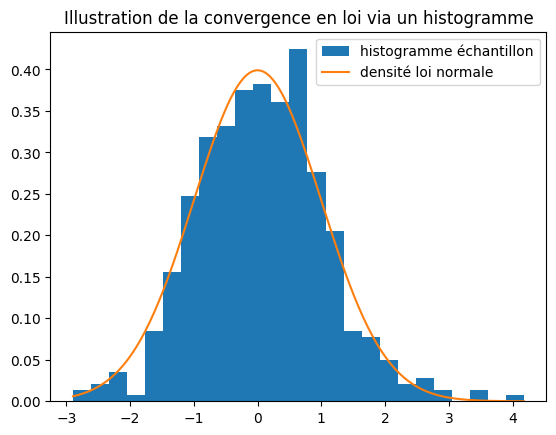

In [5]:
def illustration_cv_loi_hist_exp(l,n,N): # n est la taille des échantillons, et N le nombre des échantillons 
    M=stats.expon.rvs(scale=1/l,size=(N,n))
    L=(sqrt(n)/l)*((n/np.sum(M,axis=1))-l)
    X=np.linspace(min(L),max(L),200)
    Y=stats.norm.pdf(X)
    plt.hist(L,25,density='True', label='histogramme échantillon')
    plt.plot(X,Y,label='densité loi normale')
    plt.title('Illustration de la convergence en loi via un histogramme')
    plt.legend()
    plt.show()

illustration_cv_loi_hist_exp(2,1000,500)

Pour être rigoureux.euse, pour cette méthode il faudrait adapter la simulation dans le cas où les variables de départ sont discrètes en tracant un diagramme bâtons plutôt qu'un histogramme. Voici donc une version adaptée au cas des variables de Bernoulli. 

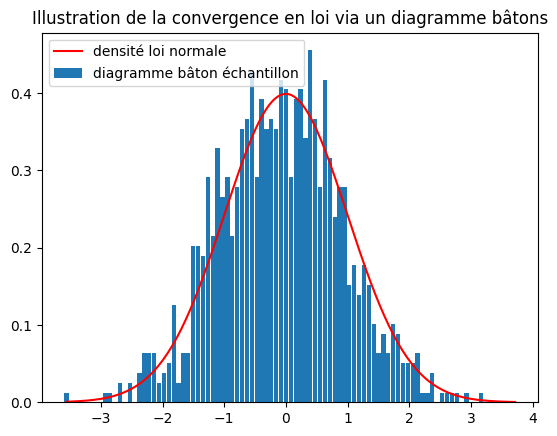

In [39]:
def illustration_cv_loi_hist_bern(p,n,N): # n est la taille des échantillons, et N le nombre des échantillons 
    S=stats.binom.rvs(n,p,size=N)
    Z=np.arange(0,n+1)
    L2=np.array([np.sum(S==z) for z in Z])
    V=(Z-n*p)/sqrt(n*p*(1-p))
    bar_width=(V[1]-V[0])
    L2=L2/(N*bar_width) # pour avoir quelque chose qui se compare bien à une densité 
    mini=np.where(L2!=0)[0][0]
    maxi=np.where(L2!=0)[0][-1]
    plt.bar(V[mini:maxi],L2[mini:maxi],bar_width-0.01,label='diagramme bâton échantillon') 
    # j'enlève le 0.01 pour que l'on voit bien qu'il s'agit d'un diagramme bâton, et non d'un histogramme (pour ne pas avoir fait tout ça pour rien...)
    # certaines bandes continuent de se coller, je n'ai pas de trouvé de réponse au pourquoi... 
    X=np.linspace(V[mini],V[maxi],200)
    Y=stats.norm.pdf(X)
    plt.plot(X,Y,'r',label='densité loi normale')
    plt.title('Illustration de la convergence en loi via un diagramme bâtons')
    plt.legend()
    plt.show()

illustration_cv_loi_hist_bern(0.8,1000,1000)  

Bon, comme vous pouvez le constater, même si ce que j'ai écrit peut sûrement être simplifié, il est tout de même plus fastidieux de tracer un diagramme bâton... et puisque le support des variables $\frac{S_n - n\mu}{\sigma \sqrt{n}}$ devient "presque" continu quand $n$ devient grand, il n'y a pas de très grande différence visuelle... Donc il vaut mieux (selon moi !) gagner du temps et faire directement un histogramme, éventuellement en se justifiant ensuite à l'oral. Exemple avec la même situation que ci dessus: 

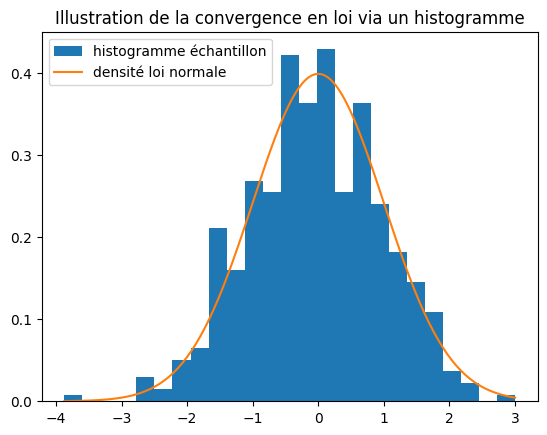

In [6]:
def illustration_cv_loi_hist_bern_de_la_flemme(p,n,N): # n est la taille des échantillons, et N le nombre des échantillons 
    S=stats.binom.rvs(n,p,size=N) #on simule directement les sommes avec des binomiales 
    L=(S-n*p)/sqrt(n*p*(1-p))
    X=np.linspace(min(L),max(L),200)
    Y=stats.norm.pdf(X)
    plt.hist(L,25,density=True,label='histogramme échantillon')
    plt.plot(X,Y,label='densité loi normale')
    plt.title('Illustration de la convergence en loi via un histogramme')
    plt.legend()
    plt.show()

illustration_cv_loi_hist_bern_de_la_flemme(0.8,1000,500)

### 2.2.3) A l'aide de diagrammes bâtons (cas discret) 

Lorsque la loi limite est discrète, il faut cette fois obligatoirement comparer des diagrammes bâtons (cette fois, le support ne devient pas continu, donc nous ne sommes plus dans le même cas qu'avant). L'exemple typique de ce genre de convergences en loi, c'est la loi des évènements rares, qui nous dit que si $(p_n)_{n \ge 1 }$ est une suite telle que $n p_n \xrightarrow[n \to \infty]{} \lambda  > 0, $ alors 
$$ \mathcal B (n,p_n)  \xrightarrow[n \to \infty]{\mathcal L } \mathcal P (\lambda). $$
Illustrons cette loi avec $p_n = \frac{\lambda}{n}$, avec $\lambda > 0$ que l'on se fixe : on simule un échantillon $(E_n^k)_{1 \le k \le N }$ de $N$ variables indépendantes qui suivent toutes une loi $\mathcal B (n,p_n)$ avant de représenter le diagramme bâtons des fréquences empiriques correspondant, et on compare ça au diagramme bâtons des probabilités d'une loi de Poisson de paramètre $\lambda$.

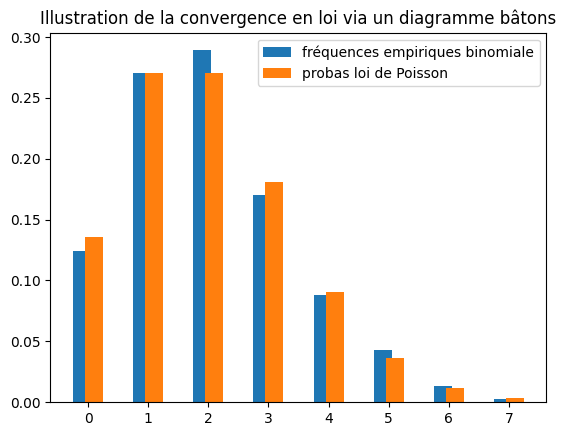

In [40]:
def illustration_cv_loi_discr(l,n,N):  
    M=stats.binom.rvs(n,l/n,size=N) 
    Z=np.arange(0,n+1)
    H_emp=np.array([np.sum(M==z)/N for z in Z])
    mini=np.where(H_emp!=0)[0][0]
    maxi=np.where(H_emp!=0)[0][-1]
    plt.bar(Z[mini:maxi+1]-0.1,H_emp[mini:maxi+1],0.3,label='fréquences empiriques binomiale')
    plt.bar(Z[mini:maxi+1]+0.1,stats.poisson.pmf(Z[mini:maxi+1],l),0.3,label='probas loi de Poisson')
    plt.title('Illustration de la convergence en loi via un diagramme bâtons')
    plt.legend() 
    plt.show()

illustration_cv_loi_discr(2,1000,1000)